In [93]:
# Basic libraries 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from pykalman import KalmanFilter
from itertools import combinations
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm
import pickle
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)

In [94]:
# Scripts 
from src.local_config import *
from src.drawdown_optimisation import * 
from src.volatility_plot import *
from src.local_config import *
from src.cointegration import *
from src.kalman import *
from src.pairs import *
from src.trading_signal import *
from src.backtest import *
from src.plots import *
from src.utils import *
from src.refined_trading_signal import *

In [95]:
# Load in data from previous notebook
df1_is = pd.read_csv(PROJECT_ROOT / "data/df1_is",
                     index_col=0, parse_dates=True)
df1_oos = pd.read_csv(PROJECT_ROOT / "data/df1_oos",
                      index_col=0, parse_dates=True)

df2_is = pd.read_csv(PROJECT_ROOT / "data/df2_is",
                     index_col=0, parse_dates=True)
df2_oos = pd.read_csv(PROJECT_ROOT / "data/df2_oos",
                      index_col=0, parse_dates=True)

static_results_df = pd.read_csv(PROJECT_ROOT / "data/static_hedge_ratio")
dynamic_results_df = pd.read_csv(PROJECT_ROOT / "data/dynamic_hedge_ratio")

In [96]:
# Load dictionaries from previous notebook
with open(PROJECT_ROOT / "data/dictionaries/static_spreads.pkl", "rb") as f:
    static_spreads = pickle.load(f)
with open(PROJECT_ROOT / "data/dictionaries/static_models.pkl", "rb") as f:
    static_models = pickle.load(f)

with open(PROJECT_ROOT / "data/dictionaries/dynamic_spreads.pkl", "rb") as f:
    dyamic_spreads = pickle.load(f)
with open(PROJECT_ROOT / "data/dictionaries/dynamic_details.pkl", "rb") as f:
    dynamic_details = pickle.load(f)

with open(PROJECT_ROOT / "data/dictionaries/is_results.pkl", "rb") as f:
    is_results = pickle.load(f)
with open(PROJECT_ROOT / "data/dictionaries/is_trading_signals.pkl", "rb") as f:
    is_trading_signals = pickle.load(f)

with open(PROJECT_ROOT / "data/dictionaries/oos_results.pkl", "rb") as f:
    oos_results = pickle.load(f)
with open(PROJECT_ROOT / "data/dictionaries/oos_trading_signals.pkl", "rb") as f:
    oos_trading_signals = pickle.load(f)

# IS & OOS Portfolios
with open(PROJECT_ROOT / "data/portfolio_is.pkl", "rb") as f:
    portfolio_is = pickle.load(f)
with open(PROJECT_ROOT / "data/portfolio_oos.pkl", "rb") as f:
    portfolio_oos = pickle.load(f)

portfolio = pd.read_csv(PROJECT_ROOT / "data/portfolio")

In [97]:
# Load dictionaries from previous notebook
# In-Sample
with open(PROJECT_ROOT / "data/dictionaries/static_spreads_is.pkl", "rb") as f:
    static_spreads_is = pickle.load(f)
with open(PROJECT_ROOT / "data/dictionaries/static_models_is.pkl", "rb") as f:
    static_models_is = pickle.load(f)

with open(PROJECT_ROOT / "data/dictionaries/dynamic_spreads_is.pkl", "rb") as f:
    dynamic_spreads_is = pickle.load(f)
with open(PROJECT_ROOT / "data/dictionaries/dynamic_details_is.pkl", "rb") as f:
    dynamic_details_is = pickle.load(f)

# Out-Of-Sample
with open(PROJECT_ROOT / "data/dictionaries/static_spreads_oos.pkl", "rb") as f:
    static_spreads_oos = pickle.load(f)
with open(PROJECT_ROOT / "data/dictionaries/static_models_oos.pkl", "rb") as f:
    static_models_oos = pickle.load(f)

with open(PROJECT_ROOT / "data/dictionaries/dynamic_spreads_oos.pkl", "rb") as f:
    dynamic_spreads_oos = pickle.load(f)
with open(PROJECT_ROOT / "data/dictionaries/dynamic_details_oos.pkl", "rb") as f:
    dynamic_details_oos = pickle.load(f)

with open(PROJECT_ROOT / "data/dictionaries/is_metrics.pkl", "rb") as f:
    is_metrics = pickle.load(f)
with open(PROJECT_ROOT / "data/dictionaries/oos_metrics.pkl", "rb") as f:
    oos_metrics = pickle.load(f)

# Load Portfolio Weighting
portfolio    = pd.read_csv(PROJECT_ROOT / "data/portfolio")
portfolio_pairs = set(portfolio["pair"])

In [98]:
# Load risk-free rate to calculate sharpe ratio
rf_is = pd.read_csv(PROJECT_ROOT / "data/rf_is",
                     index_col=0, parse_dates=True) 
rf_oos = pd.read_csv(PROJECT_ROOT / "data/rf_oos",
                     index_col=0, parse_dates=True)

# Enhanced Trading Signal Workflow 
1) Estimate Volatility using the return of the spread at time $t-i$
2) Calculate maximum drawdown threshold based off of the spread's volatlity 
3) Adjust the trading signals accordingly with the updated risk parameters and dynamic z-score bands

## Estimated Volatility Formula (*using EWMA*)
Calculated in calculate_vol function:
$$
\hat{\sigma_t}=\sqrt{\frac{\sum_{i=0}^tw_i(r_{t-i}-\mu_t)^2}{\sum_{i=0}^tw_i}}
$$

## Drawdown Threshold Formula
Calculated in drawdown_thresholds function:
$$
\text{Drawdown}=k_{m}\times\sigma_{i,t}\times\sqrt{H}
$$

Where:
- m is either the volatility multiplier coefficient for **reducing** position size or **closing** a position
- $\sigma_{i,t}$ is the estimated volatility from above for pair i
- H is the holding period (which we have fixed to 10 days for simplicity) 

In [99]:
is_extraction = extractor(is_results)
oos_extraction = extractor(oos_results)

In [100]:
is_extraction.head()

,date,strategy,pair,obs_cov,spread_t,position,spread_change,strategy_ret
1,2015-03-31,entry_1.5_exit_0.0,1347 HK Equity vs 268 HK Equity,0.5,-0.064534,0.0,0.015177,0.0
2,2015-04-01,entry_1.5_exit_0.0,1347 HK Equity vs 268 HK Equity,0.5,-0.080450,0.0,-0.015916,-0.0
3,2015-04-02,entry_1.5_exit_0.0,1347 HK Equity vs 268 HK Equity,0.5,-0.092410,0.0,-0.011960,-0.0
4,2015-04-08,entry_1.5_exit_0.0,1347 HK Equity vs 268 HK Equity,0.5,-0.081074,0.0,0.011335,0.0
5,2015-04-09,entry_1.5_exit_0.0,1347 HK Equity vs 268 HK Equity,0.5,-0.066418,0.0,0.014657,0.0


In [101]:
oos_extraction.head()

,date,strategy,pair,obs_cov,spread_t,position,spread_change,strategy_ret
1,2022-12-29,entry_1.5_exit_0.0,1347 HK Equity vs 268 HK Equity,0.5,-0.082714,0.0,0.006693,0.000000
2,2022-12-30,entry_1.5_exit_0.0,1347 HK Equity vs 268 HK Equity,0.5,-0.078146,0.0,0.004568,0.000000
3,2023-01-03,entry_1.5_exit_0.0,1347 HK Equity vs 268 HK Equity,0.5,-0.136280,1.0,-0.058134,-0.000000
4,2023-01-04,entry_1.5_exit_0.0,1347 HK Equity vs 268 HK Equity,0.5,-0.171563,1.0,-0.035283,-0.035283
5,2023-01-05,entry_1.5_exit_0.0,1347 HK Equity vs 268 HK Equity,0.5,-0.122898,1.0,0.048664,0.048664


In [102]:
is_volatility = pair_volatility(is_extraction)
is_drawdown_values = drawdown_thresholds(is_volatility)

oos_volatility = pair_volatility(oos_extraction)
oos_drawdown_values = drawdown_thresholds(oos_volatility)

In [103]:
# Portfolio Drawdown Values
# In-Sample
strategy_name = "entry_1.5_exit_0.5"

drawdown_thresholds_is = is_drawdown_values[
    is_drawdown_values["strategy"] == strategy_name
][["date", "pair", "obs_cov", "reduce_drawdown_threshold", "close_drawdown_threshold"]]

# Out-of-Sample
drawdown_thresholds_oos = oos_drawdown_values[
    oos_drawdown_values["strategy"] == strategy_name
][["date", "pair", "obs_cov", "reduce_drawdown_threshold", "close_drawdown_threshold"]]

## Generating Refined Trading Signals

In [104]:
weights = portfolio.set_index("pair")["weight"].to_dict()
portfolio_pairs = set(portfolio["pair"])

dynamic_details_portfolio_is = {
    k: v for k, v in dynamic_details_is.items()
    if k[0] in portfolio_pairs
}

dynamic_details_portfolio_oos = {
    k: v for k, v in dynamic_details_oos.items()
    if k[0] in portfolio_pairs
}

In [105]:
is_signals_df  = generate_refined_kalman_signals_1(
    dynamic_details     = dynamic_details_portfolio_is,
    drawdown_thresholds = drawdown_thresholds_is   
)

oos_signals_df = generate_refined_kalman_signals_1(
    dynamic_details     = dynamic_details_portfolio_oos,
    drawdown_thresholds = drawdown_thresholds_oos
)

In [106]:
is_signals_df.head()

,y,x,alpha_t,beta_t,spread_t,obs_cov,rolling_mean,rolling_std,zscore,upper_band,...,trade_equity,running_peak,trade_drawdown,risk_state,z_window,band_window,upper_quantile,lower_quantile,exit_z,reduced_exposure
date,,,,,,,,,,,,,,,,,,,,,
2015-10-05,1.982931,1.133336,1.519282,0.400839,0.009364,0.5,-0.091442,0.052856,1.907168,1.184569,...,0.000000,0.000000,0.000000,normal,60,126,0.8,0.2,0.5,0.5
2015-10-06,1.977962,1.110870,1.519545,0.400863,0.013110,0.5,-0.088952,0.054209,1.882753,1.192257,...,-0.003747,0.000000,-0.003747,normal,60,126,0.8,0.2,0.5,0.5
2015-10-07,1.990337,1.155623,1.519657,0.400910,0.007380,0.5,-0.087232,0.055607,1.701447,1.225606,...,0.001984,0.001984,0.000000,normal,60,126,0.8,0.2,0.5,0.5
2015-10-08,1.972969,1.146132,1.519560,0.400877,-0.006048,0.5,-0.086024,0.056578,1.413564,1.246997,...,0.015412,0.015412,0.000000,normal,60,126,0.8,0.2,0.5,0.5
2015-10-09,1.974220,1.152469,1.519451,0.400832,-0.007177,0.5,-0.085581,0.057095,1.373221,1.258456,...,0.016541,0.016541,0.000000,normal,60,126,0.8,0.2,0.5,0.5


In [107]:
portfolio  = pd.read_csv(PROJECT_ROOT / "data/portfolio")
weights    = portfolio.set_index("pair")["weight"].to_dict()
obs_cov    = 1.0

def aggregate_refined_portfolio(signals_df, weights, obs_cov):
    filtered = signals_df[
        (np.isclose(signals_df["obs_cov"], obs_cov)) &
        (signals_df["pair"].isin(weights))
    ].copy()

    filtered["spread_change"] = filtered.groupby("pair")["spread_t"].diff()
    filtered["strategy_ret"]  = (
        filtered["active_position"]
        * filtered["spread_change"]
        * filtered["pair"].map(weights)
    )

    return filtered.groupby(filtered.index)["strategy_ret"].sum()

is_portfolio_ret  = aggregate_refined_portfolio(is_signals_df,  weights, obs_cov)
oos_portfolio_ret = aggregate_refined_portfolio(oos_signals_df, weights, obs_cov)

In [108]:
is_refined_metrics  = performance_metrics(is_portfolio_ret,  rf=rf_is)
oos_refined_metrics = performance_metrics(oos_portfolio_ret, rf=rf_oos)

pd.DataFrame([is_refined_metrics, oos_refined_metrics], index=["In-Sample", "Out-of-Sample"])

,avg_return (%),avg_excess_return (%),annualised_sharpe,total_pnl,hit_rate (%),max_drawdown (%),num_obs
In-Sample,0.1640,0.1729,1.7641,1279.49,54.41,-21.93,1724.0
Out-of-Sample,0.1226,0.1096,1.0884,95.78,55.20,-15.43,612.0


In [109]:
# Comparison table between baseline and refined
comparison = pd.concat([
    pd.DataFrame([is_metrics, oos_metrics], index=["IS", "OOS"]).add_prefix("baseline_"),
    pd.DataFrame([is_refined_metrics, oos_refined_metrics],  index=["IS", "OOS"]).add_prefix("refined_"),
], axis=1)

comparison

,baseline_avg_return (%),baseline_avg_excess_return (%),baseline_annualised_sharpe,baseline_total_pnl,baseline_hit_rate (%),baseline_max_drawdown (%),baseline_num_obs,refined_avg_return (%),refined_avg_excess_return (%),refined_annualised_sharpe,refined_total_pnl,refined_hit_rate (%),refined_max_drawdown (%),refined_num_obs
IS,0.1435,0.1523,1.6959,1093.60,54.18,-23.12,1850.0,0.1640,0.1729,1.7641,1279.49,54.41,-21.93,1724.0
OOS,0.1559,0.1435,1.5842,192.75,58.44,-15.64,738.0,0.1226,0.1096,1.0884,95.78,55.20,-15.43,612.0


## Refined Trading Signal w/o Drawdown Parameter

In [110]:
is_signals_2_df = generate_refined_kalman_signals_2(
    dynamic_details_portfolio_is,
    use_fixed_bands=False,
    upper_quantile=0.80,
    lower_quantile=0.20
)

oos_signals_2_df = generate_refined_kalman_signals_2(
    dynamic_details = dynamic_details_portfolio_oos,
    use_fixed_bands=False,
    upper_quantile=0.80,
    lower_quantile=0.20
)

/var/folders/by/g895l7l128j9y19qqn66xcxh0000gn/T/ipykernel_49518/2742992742.py:1: UserWarning: Rolling quantile bands on an already-standardised z-score produce near-constant thresholds. Consider use_fixed_bands=True instead.
  is_signals_2_df = generate_refined_kalman_signals_2(
/var/folders/by/g895l7l128j9y19qqn66xcxh0000gn/T/ipykernel_49518/2742992742.py:8: UserWarning: Rolling quantile bands on an already-standardised z-score produce near-constant thresholds. Consider use_fixed_bands=True instead.
  oos_signals_2_df = generate_refined_kalman_signals_2(


In [111]:
is_portfolio_ret_2  = aggregate_refined_portfolio(is_signals_2_df,  weights, obs_cov)
oos_portfolio_ret_2 = aggregate_refined_portfolio(oos_signals_2_df, weights, obs_cov)

In [112]:
is_refined_metrics_2  = performance_metrics(is_portfolio_ret_2,  rf=rf_is)
oos_refined_metrics_2 = performance_metrics(oos_portfolio_ret_2, rf=rf_oos)

pd.DataFrame([is_refined_metrics_2, oos_refined_metrics_2], index=["In-Sample", "Out-of-Sample"])

,avg_return (%),avg_excess_return (%),annualised_sharpe,total_pnl,hit_rate (%),max_drawdown (%),num_obs
In-Sample,0.1591,0.1692,1.7203,1166.26,54.12,-21.93,1724.0
Out-of-Sample,0.1199,0.1070,1.0473,92.20,55.03,-15.43,612.0


In [113]:
# Comparison table between baseline and refined (w/o drawdown)
comparison_2 = pd.concat([
    pd.DataFrame([is_metrics, oos_metrics], index=["IS", "OOS"]).add_prefix("baseline_"),
    pd.DataFrame([is_refined_metrics_2, oos_refined_metrics_2],  index=["IS", "OOS"]).add_prefix("refined_"),
], axis=1)

comparison_2

,baseline_avg_return (%),baseline_avg_excess_return (%),baseline_annualised_sharpe,baseline_total_pnl,baseline_hit_rate (%),baseline_max_drawdown (%),baseline_num_obs,refined_avg_return (%),refined_avg_excess_return (%),refined_annualised_sharpe,refined_total_pnl,refined_hit_rate (%),refined_max_drawdown (%),refined_num_obs
IS,0.1435,0.1523,1.6959,1093.60,54.18,-23.12,1850.0,0.1591,0.1692,1.7203,1166.26,54.12,-21.93,1724.0
OOS,0.1559,0.1435,1.5842,192.75,58.44,-15.64,738.0,0.1199,0.1070,1.0473,92.20,55.03,-15.43,612.0


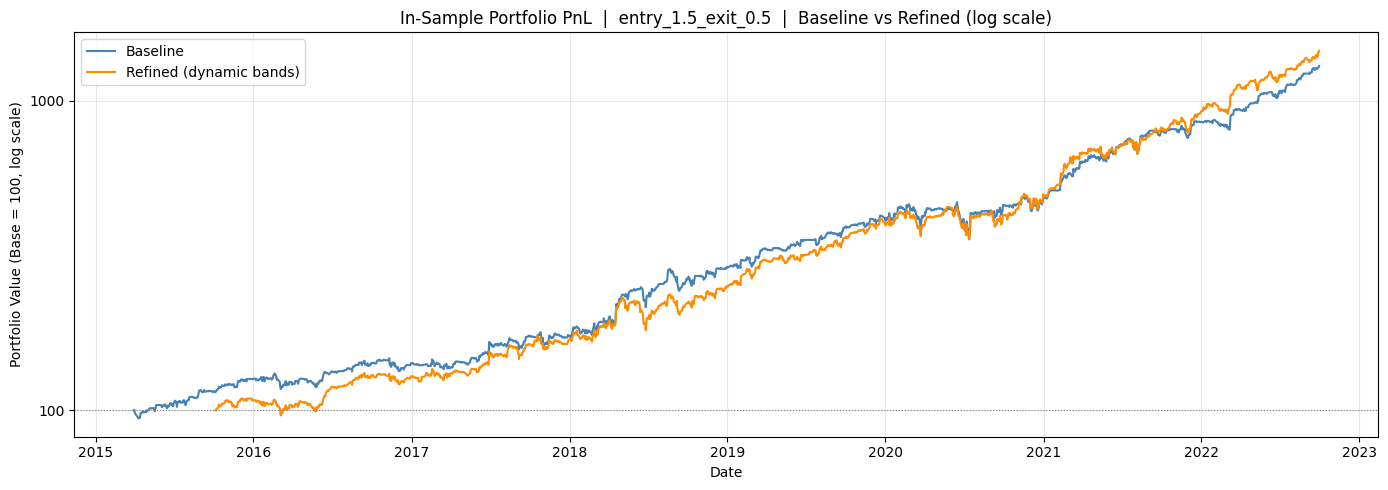

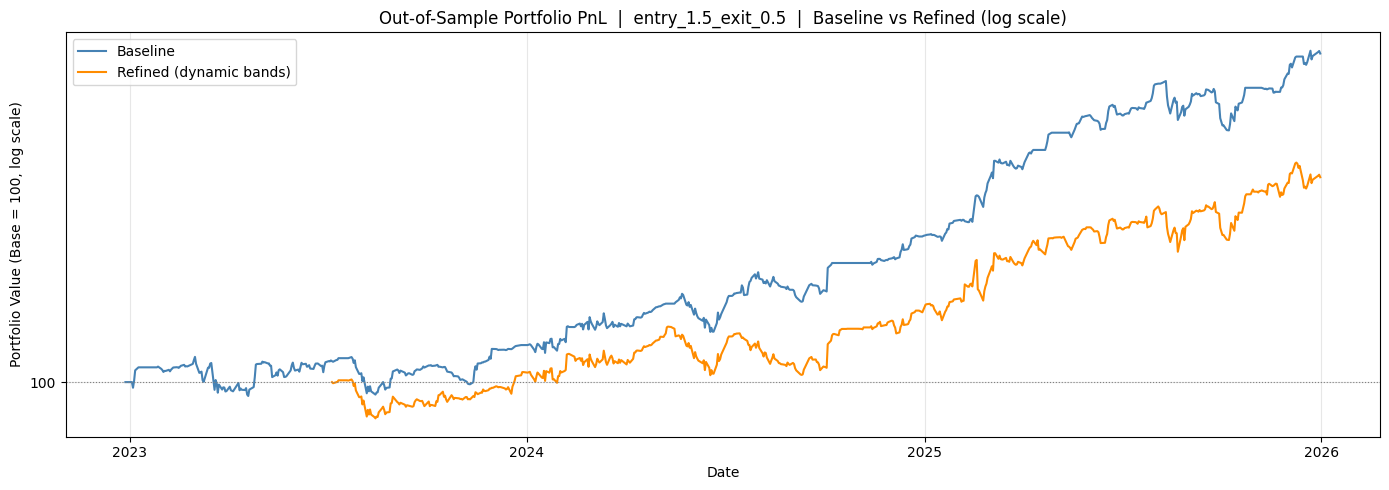

In [115]:
save_dir = PROJECT_ROOT / "outputs/refined_trading_signal"
os.makedirs(save_dir, exist_ok=True)

def build_portfolio_ret(results, strategy_name, weights, obs_cov):
    pair_rets = {}
    for (pair_name, R), df in results[strategy_name].items():
        if not np.isclose(float(R), obs_cov) or pair_name not in weights:
            continue
        df = compute_strategy_returns(df.copy())
        pair_rets[pair_name] = df["strategy_ret"] * weights[pair_name]
    return pd.DataFrame(pair_rets).sum(axis=1)

is_baseline  = build_portfolio_ret(is_results,  strategy_name, weights, obs_cov)
oos_baseline = build_portfolio_ret(oos_results, strategy_name, weights, obs_cov)

is_cum_base  = 100 * (1 + is_baseline.fillna(0)).cumprod()
oos_cum_base = 100 * (1 + oos_baseline.fillna(0)).cumprod()
is_cum_ref   = 100 * (1 + is_portfolio_ret.fillna(0)).cumprod()
oos_cum_ref  = 100 * (1 + oos_portfolio_ret.fillna(0)).cumprod()

for cum_base, cum_ref, label in [
    (is_cum_base,  is_cum_ref,  "In_Sample"),
    (oos_cum_base, oos_cum_ref, "Out_of_Sample"),
]:
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(cum_base.index, cum_base, color="steelblue",  lw=1.5, label="Baseline")
    ax.plot(cum_ref.index,  cum_ref,  color="darkorange", lw=1.5, label="Refined (dynamic bands)")
    ax.axhline(100, color="grey", linestyle=":", lw=0.8)
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=10))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.set_title(f"{label.replace('_', '-')} Portfolio PnL  |  {strategy_name}  |  Baseline vs Refined (log scale)")
    ax.set_ylabel("Portfolio Value (Base = 100, log scale)")
    ax.set_xlabel("Date")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(save_dir / f"{label}_{strategy_name}_baseline_vs_refined.png", dpi=300, bbox_inches="tight")
    plt.show()

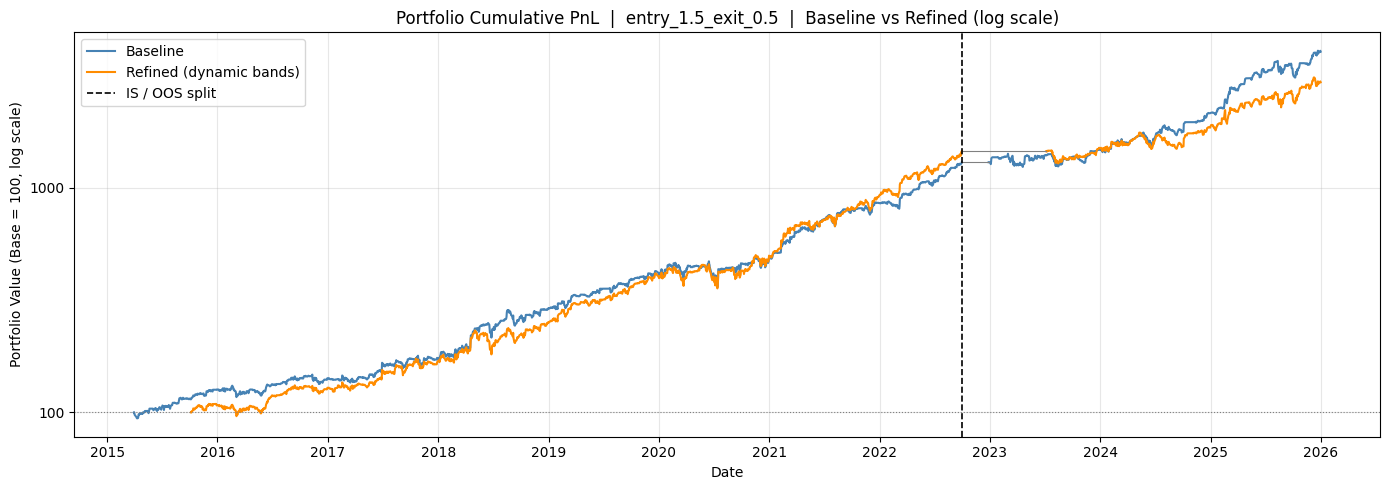

In [116]:
oos_cum_base_cont = is_cum_base.iloc[-1] * (1 + oos_baseline.fillna(0)).cumprod()
oos_cum_ref_cont  = is_cum_ref.iloc[-1]  * (1 + oos_portfolio_ret.fillna(0)).cumprod()

fig, ax = plt.subplots(figsize=(14, 5))
for is_cum, oos_cum, color, label in [
    (is_cum_base, oos_cum_base_cont, "steelblue",  "Baseline"),
    (is_cum_ref,  oos_cum_ref_cont,  "darkorange", "Refined (dynamic bands)"),
]:
    ax.plot(is_cum.index,  is_cum,  color=color, lw=1.5, label=label)
    ax.plot(oos_cum.index, oos_cum, color=color, lw=1.5)
    ax.plot([is_cum.index[-1], oos_cum.index[0]],
            [is_cum.iloc[-1],  oos_cum.iloc[0]], color="grey", lw=0.8)

ax.axvline(is_cum_base.index[-1], color="black", linestyle="--", lw=1.2, label="IS / OOS split")
ax.axhline(100, color="grey", linestyle=":", lw=0.8)
ax.set_yscale("log")
ax.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=10))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.yaxis.set_minor_locator(mticker.NullLocator())
ax.set_title(f"Portfolio Cumulative PnL  |  {strategy_name}  |  Baseline vs Refined (log scale)")
ax.set_ylabel("Portfolio Value (Base = 100, log scale)")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(save_dir / f"Combined_{strategy_name}_baseline_vs_refined.png", dpi=300, bbox_inches="tight")
plt.show()